# Emulator listening demo

Pick a **device** and an **audio source**, press **Run**, and listen to
*clean → real render (target) → model prediction* side by side.

- Kernel: select the **open-amp3000** conda env (Python 3.10).
- Runs on **CPU** so it never competes with a live training run.
- The checkpoint is copied to a temp file before loading, so it is safe to use
  while training is still writing new checkpoints — re-run the setup cell any
  time to pick up the latest best.
- Corpus files come with the real render as reference; an **external file**
  (any wav/flac guitar DI) gives prediction only.

In [1]:
import os, shutil, tempfile
from pathlib import Path

# run from the repo root so the config's relative data paths resolve
if not Path('configs').is_dir() and (Path.cwd().parent / 'configs').is_dir():
    os.chdir(Path.cwd().parent)
print('cwd:', Path.cwd())

import numpy as np
import pandas as pd
import torch

from openamp.core.config import load_config
from openamp.dsp.audio import audio_info, seek_read
from openamp.emulate.evaluate import load_model

RUN_DIR = Path('results/emulate/wavenet_a2')   # <- change to compare other runs

cfg = load_config()
with tempfile.TemporaryDirectory() as td:
    shutil.copy(RUN_DIR / 'checkpoint.pt', Path(td) / 'checkpoint.pt')
    model, ck = load_model(Path(td), 'cpu')
model.eval()
R = int(ck['receptive_field'])
ID2ROW = ck['id_to_idx']

# device catalog (make/model/gain labels), restricted to the checkpoint's table
cat = pd.read_parquet('data/manifests/manifest.parquet').drop_duplicates('device_id')
cat = cat[cat['device_id'].isin(ID2ROW)].set_index('device_id')

# corpus files (these have real renders to compare against)
corpus = pd.read_parquet(cfg.corpus_manifest_path)
corpus = corpus.sort_values(['split', 'file_id'])

print(f"run: {ck['name']}  epoch={ck['epoch']}  val_esr={ck['val_esr']:.4f}")
print(f"devices in table: {len(ID2ROW)}   corpus files: {len(corpus)}   "
      f"receptive field: {R} samples ({1000 * R / cfg.sample_rate:.1f} ms)")

cwd: /m/home/home3/37/thieun1/unix/Project/Open-Amp3000
run: wavenet_a2  epoch=76  val_esr=0.1198
devices in table: 405   corpus files: 88   receptive field: 6347 samples (132.2 ms)


In [2]:
import auraloss
from scipy.signal import resample_poly

from openamp.emulate.train import preemph_esr


def read_clean_window(file_id: str, split: str, start_s: float, dur_s: float):
    """Clean corpus audio [start, start+dur) with R samples of real left-context."""
    path = cfg.clean_split_dir(split) / f'{file_id}.{cfg.output_format}'
    n = audio_info(path)[0]
    clip = int(dur_s * cfg.sample_rate)
    c = min(int(start_s * cfg.sample_rate), max(n - clip, 0))
    clip = min(clip, n - c)
    s, pad = c - R, 0
    if s < 0:
        pad, s = -s, 0
    x = seek_read(path, s, R + clip - pad)
    if pad:
        x = np.concatenate([np.zeros(pad, np.float32), x])
    return x, c, clip


def read_target_window(device_id: int, file_id: str, c: int, clip: int):
    path = cfg.device_render_dir(device_id) / f'{file_id}.{cfg.output_format}'
    if not path.is_file():
        return None
    try:
        return seek_read(path, c, clip)
    except Exception as e:                      # rare libsndfile seek quirk
        print(f'(no target: {e!r})')
        return None


def read_external(path: str, start_s: float, dur_s: float):
    """Any wav/flac: mono-mix, resample to 48 kHz, cut the window, zero context."""
    import soundfile as sf
    x, sr = sf.read(path, dtype='float32')
    if x.ndim > 1:
        x = x.mean(axis=1)
    if sr != cfg.sample_rate:
        x = resample_poly(x, cfg.sample_rate, sr).astype(np.float32)
    c = int(start_s * cfg.sample_rate)
    x = x[c:c + int(dur_s * cfg.sample_rate)]
    peak = np.abs(x).max()
    if peak > 0:                                # match corpus headroom roughly
        x = 0.5 * x / peak
    return np.concatenate([np.zeros(R, np.float32), x]), None, len(x)


@torch.no_grad()
def emulate(clean_with_ctx: np.ndarray, device_id: int) -> np.ndarray:
    row = torch.tensor([ID2ROW[int(device_id)]])
    x = torch.from_numpy(clean_with_ctx)[None]
    return model(x, row)[0, 0, R:].numpy()


def esr(pred, target):
    return float(((pred - target) ** 2).sum() / ((target ** 2).sum() + 1e-8))


MRSTFT = auraloss.freq.MultiResolutionSTFTLoss()   # same defaults as training


@torch.no_grad()
def window_metrics(pred: np.ndarray, target: np.ndarray):
    """Plain ESR plus the two training-loss terms (pre-emph ESR, MR-STFT)."""
    p = torch.from_numpy(pred)[None, None]
    t = torch.from_numpy(np.ascontiguousarray(target))[None, None]
    return (esr(pred, target),
            float(preemph_esr(p, t, cfg.emulate.preemph)),
            float(MRSTFT(p, t)))

print('engine ready')

engine ready


In [3]:
from time import perf_counter

import ipywidgets as W
from IPython.display import Audio, display


def _dev_label(d):
    r = cat.loc[d]
    return f"{d:4d} · {r['make']} {r['model']} ({r.get('gain_bucket', '?')})"


dev_dd = W.Dropdown(options=[(_dev_label(d), d) for d in sorted(ID2ROW)],
                    description='Device')
file_dd = W.Dropdown(options=[(f"{r.file_id} · {r.split} · {r.duration_s:.0f}s",
                               (r.file_id, r.split))
                              for r in corpus.itertuples(index=False)],
                     description='Audio')
ext_txt = W.Text(value='', placeholder='(optional) /path/to/your_guitar_DI.wav',
                 description='External', layout=W.Layout(width='60%'))
start_sl = W.FloatSlider(value=0.0, min=0.0, max=60.0, step=0.5, description='Start s')
dur_sl = W.FloatSlider(value=8.0, min=2.0, max=20.0, step=1.0, description='Length s')
run_btn = W.Button(description='Run', button_style='primary')
out = W.Output()


def on_run(_):
    out.clear_output()
    with out:
        d = dev_dd.value
        if ext_txt.value.strip():
            x, c, clip = read_external(ext_txt.value.strip(),
                                       start_sl.value, dur_sl.value)
            target, src = None, Path(ext_txt.value).name
        else:
            fid, split = file_dd.value
            x, c, clip = read_clean_window(fid, split, start_sl.value, dur_sl.value)
            target = read_target_window(d, fid, c, clip)
            src = f'{fid} ({split})'
            
        t0 = perf_counter()
        pred = emulate(x, d)
        dt = perf_counter() - t0
        audio_s = clip / cfg.sample_rate
        samples_p_s = clip / dt
        print(f'{_dev_label(d)}   |   {src}   |   {audio_s:.1f}s')
        print(f'render speed: {audio_s:.1f}s of audio in {dt:.2f}s on CPU '
              f'({audio_s / dt:.2f}× realtime), {samples_p_s:.1f} samples/s, 1024 samples in {1024 / samples_p_s:.4f}s')

        if target is not None:
            e, pe, mr = window_metrics(pred, target)
            print(f'window metrics (pred vs real render):  '
                  f'ESR {e:.4f}   pre-emph ESR {pe:.4f}   MR-STFT {mr:.4f}   '
                  f'train loss {pe + cfg.emulate.stft_weight * mr:.4f}')
        print('\nclean input:')
        display(Audio(x[R:], rate=cfg.sample_rate, normalize=False))
        if target is not None:
            print('real render (target):')
            display(Audio(target, rate=cfg.sample_rate, normalize=False))
        print('model prediction:')
        display(Audio(np.clip(pred, -1, 1), rate=cfg.sample_rate, normalize=False))


run_btn.on_click(on_run)
display(W.VBox([dev_dd, file_dd, ext_txt, W.HBox([start_sl, dur_sl]), run_btn, out]))

**Notes**

- *Device* lists the 405 devices in the model's embedding table (the 45 held-out
  enrollment devices have no row yet, so they cannot be demoed until Phase 5).
- *Audio* = corpus files; val/test files are material the model never trained on.
  The **window metrics** are computed on just that window, with the same
  definitions as training: plain (un-pre-emphasized) **ESR**, **pre-emph ESR**
  (coeff from config, default 0.85), **MR-STFT** (auraloss multi-resolution
  STFT), and **train loss** = pre-emph ESR + stft_weight · MR-STFT.
- *External* overrides the corpus pick: any wav/flac (mono-mixed, resampled to
  48 kHz, peak-normalized to 0.5). There is no reference render, so you get
  clean + prediction only.
- Re-run the **setup cell** to reload the latest best checkpoint mid-training.

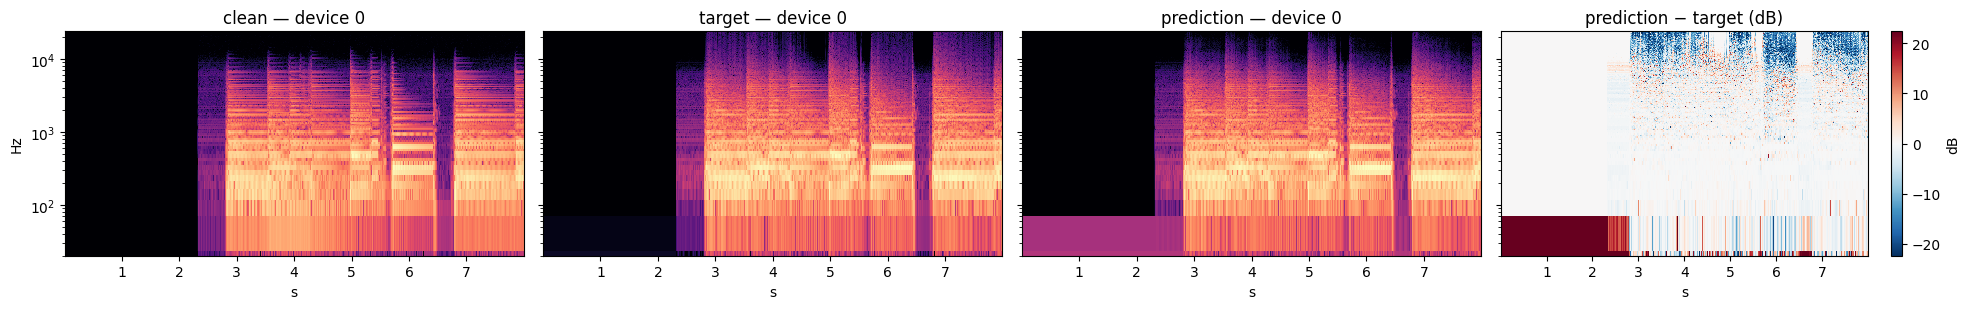

In [4]:
# Optional: spectrograms of the last Run (execute after pressing Run).
# Reads the widgets' current selection and recomputes — cheap on CPU.
# Log-frequency axis; when a real render exists, a 4th panel shows the signed
# spectral error (prediction − target, dB): red = model too loud, blue = too quiet.
import matplotlib.pyplot as plt
from matplotlib import mlab

d = dev_dd.value
if ext_txt.value.strip():
    x, c, clip = read_external(ext_txt.value.strip(), start_sl.value, dur_sl.value)
    target = None
else:
    fid, split = file_dd.value
    x, c, clip = read_clean_window(fid, split, start_sl.value, dur_sl.value)
    target = read_target_window(d, fid, c, clip)
pred = emulate(x, d)

stft = dict(NFFT=1024, noverlap=512, Fs=cfg.sample_rate)
panels = [('clean', x[R:]), ('prediction', pred)]
if target is not None:
    panels.insert(1, ('target', target))
P = {}
for title, sig in panels:
    P[title], freqs, bins = mlab.specgram(sig, **stft)

n = len(panels) + (target is not None)          # extra slot for the difference
fig, axes = plt.subplots(1, n, figsize=(5 * n, 3.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, (title, _) in zip(axes, panels):
    S = 10 * np.log10(np.maximum(P[title], P[title].max() * 1e-10))
    ax.pcolormesh(bins, freqs, S, cmap='magma', shading='auto')
    ax.set_title(f'{title} — device {d}')
    ax.set_xlabel('s')

if target is not None:
    # clamp to a −100 dB-relative floor so near-silent bins read as
    # "no difference" instead of the ratio of two noise values
    P_t, P_p = P['target'], P['prediction']
    floor = max(P_t.max(), P_p.max()) * 1e-10
    diff = (10 * np.log10(np.maximum(P_p, floor))
            - 10 * np.log10(np.maximum(P_t, floor)))
    lim = max(np.percentile(np.abs(diff), 98), 1.0)   # robust symmetric range
    ax = axes[-1]
    m = ax.pcolormesh(bins, freqs, diff, cmap='RdBu_r', vmin=-lim, vmax=lim,
                      shading='auto')
    ax.set_title('prediction − target (dB)')
    ax.set_xlabel('s')
    fig.colorbar(m, ax=ax, label='dB')

for ax in axes:
    ax.set_yscale('log')
axes[0].set_ylim(20, cfg.sample_rate / 2)
axes[0].set_ylabel('Hz')
plt.tight_layout(); plt.show()